In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('ggplot')

os.makedirs("cleaned_data", exist_ok=True)
os.makedirs("visuals", exist_ok=True)
os.makedirs("reports", exist_ok=True)

In [2]:
#Load Datasets
covid = pd.read_csv(
    "dataset/covid_19_india.csv"
)
vaccine = pd.read_csv(
    "dataset/covid_vaccine_statewise.csv"
)
testing = pd.read_csv(
    "dataset/StatewiseTestingDetails.csv"
)

In [3]:
#Display First Rows
print("\nCOVID DATA")
print(covid.head())
print("\nVACCINE DATA")
print(vaccine.head())
print("\nTESTING DATA")
print(testing.head())


COVID DATA
   Sno        Date     Time State/UnionTerritory ConfirmedIndianNational  \
0    1  2020-01-30  6:00 PM               Kerala                       1   
1    2  2020-01-31  6:00 PM               Kerala                       1   
2    3  2020-02-01  6:00 PM               Kerala                       2   
3    4  2020-02-02  6:00 PM               Kerala                       3   
4    5  2020-02-03  6:00 PM               Kerala                       3   

  ConfirmedForeignNational  Cured  Deaths  Confirmed  
0                        0      0       0          1  
1                        0      0       0          1  
2                        0      0       0          2  
3                        0      0       0          3  
4                        0      0       0          3  

VACCINE DATA
   Updated On  State  Total Doses Administered  Sessions   Sites   \
0  16/01/2021  India                   48276.0    3455.0   2957.0   
1  17/01/2021  India                   58604.0   

In [4]:
#Dataset Information
print("\nCOVID INFO")
print(covid.info())
print("\nVACCINE INFO")
print(vaccine.info())
print("\nTESTING INFO")
print(testing.info())


COVID INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Sno                       18110 non-null  int64 
 1   Date                      18110 non-null  object
 2   Time                      18110 non-null  object
 3   State/UnionTerritory      18110 non-null  object
 4   ConfirmedIndianNational   18110 non-null  object
 5   ConfirmedForeignNational  18110 non-null  object
 6   Cured                     18110 non-null  int64 
 7   Deaths                    18110 non-null  int64 
 8   Confirmed                 18110 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.2+ MB
None

VACCINE INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7845 entries, 0 to 7844
Data columns (total 24 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --

In [5]:
#Statistical Summary
print("\nCOVID STATISTICAL SUMMARY")
print(covid.describe())


COVID STATISTICAL SUMMARY
                Sno         Cured         Deaths     Confirmed
count  18110.000000  1.811000e+04   18110.000000  1.811000e+04
mean    9055.500000  2.786375e+05    4052.402264  3.010314e+05
std     5228.051023  6.148909e+05   10919.076411  6.561489e+05
min        1.000000  0.000000e+00       0.000000  0.000000e+00
25%     4528.250000  3.360250e+03      32.000000  4.376750e+03
50%     9055.500000  3.336400e+04     588.000000  3.977350e+04
75%    13582.750000  2.788698e+05    3643.750000  3.001498e+05
max    18110.000000  6.159676e+06  134201.000000  6.363442e+06


In [6]:
#Check Missing Values
print("\nMISSING VALUES")
print(covid.isnull().sum())


MISSING VALUES
Sno                         0
Date                        0
Time                        0
State/UnionTerritory        0
ConfirmedIndianNational     0
ConfirmedForeignNational    0
Cured                       0
Deaths                      0
Confirmed                   0
dtype: int64


In [7]:
#Handle Missing Values
covid.fillna(0, inplace=True)
vaccine.fillna(0, inplace=True)
testing.fillna(0, inplace=True)

In [8]:
#Remove Duplicates
print("\nDUPLICATES:",
      covid.duplicated().sum())

covid.drop_duplicates(inplace=True)


DUPLICATES: 0


In [9]:
#Convert Date Column
covid['Date'] = pd.to_datetime(
    covid['Date']
)

In [10]:
#Save Cleaned Data
covid.to_csv(
    "cleaned_data/cleaned_covid_data.csv",
    index=False
)

In [11]:
#Total Cases Analysis
total_confirmed = covid['Confirmed'].sum()
total_deaths = covid['Deaths'].sum()
total_cured = covid['Cured'].sum()

print("\nTOTAL CONFIRMED CASES:",
      total_confirmed)
print("\nTOTAL DEATHS:",
      total_deaths)
print("\nTOTAL CURED:",
      total_cured)


TOTAL CONFIRMED CASES: 5451678687

TOTAL DEATHS: 73389005

TOTAL CURED: 5046125452


In [12]:
#State Wise Analysis
state_cases = covid.groupby(
    'State/UnionTerritory'
)['Confirmed'].max().sort_values(
    ascending=False
)

print("\nTOP 10 STATES")
print(state_cases.head(10))


TOP 10 STATES
State/UnionTerritory
Maharashtra       6363442
Maharashtra***    6229596
Kerala            3586693
Karnataka         2921049
Karanataka        2885238
Tamil Nadu        2579130
Andhra Pradesh    1985182
Uttar Pradesh     1708812
West Bengal       1534999
Delhi             1436852
Name: Confirmed, dtype: int64


In [13]:
#Daily Trend Analysis
daily_cases = covid.groupby(
    'Date'
)['Confirmed'].sum()

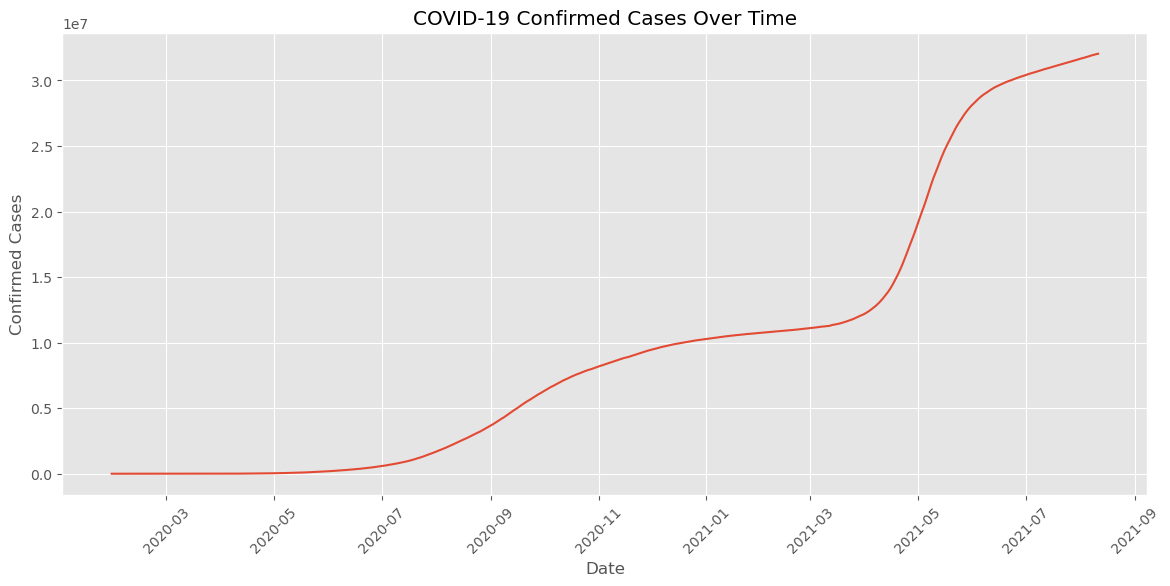

In [14]:
#Line Plot - Daily Cases
plt.figure(figsize=(14,6))
plt.plot(daily_cases)
plt.title("COVID-19 Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)

plt.savefig(
    "visuals/daily_cases_lineplot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

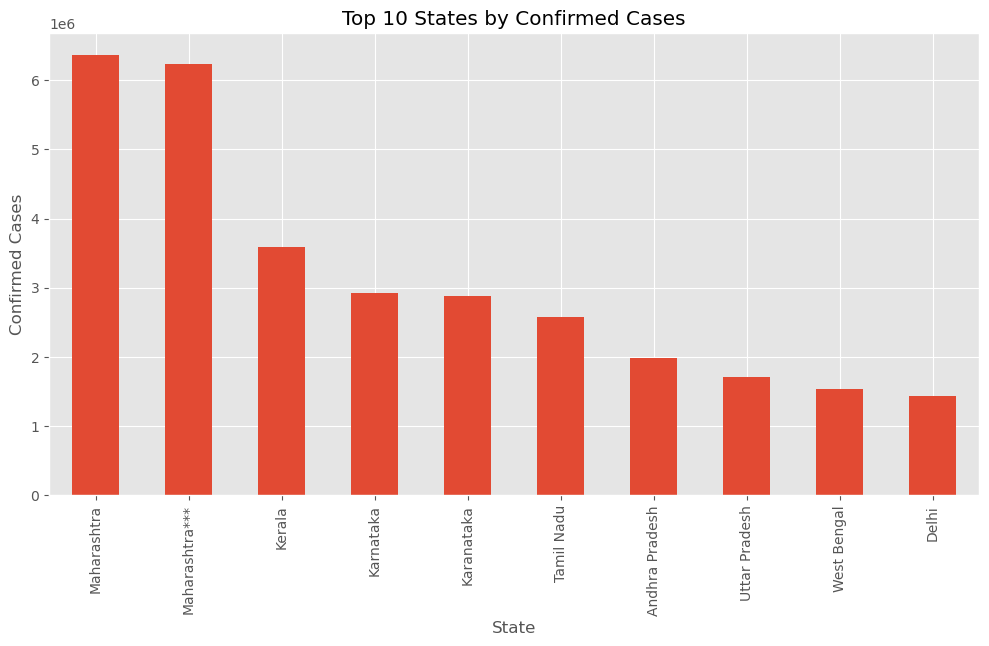

In [15]:
#Bar Chart - Top States
plt.figure(figsize=(12,6))
state_cases.head(10).plot(kind='bar')
plt.title("Top 10 States by Confirmed Cases")
plt.xlabel("State")
plt.ylabel("Confirmed Cases")

plt.savefig(
    "visuals/top_states_barchart.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

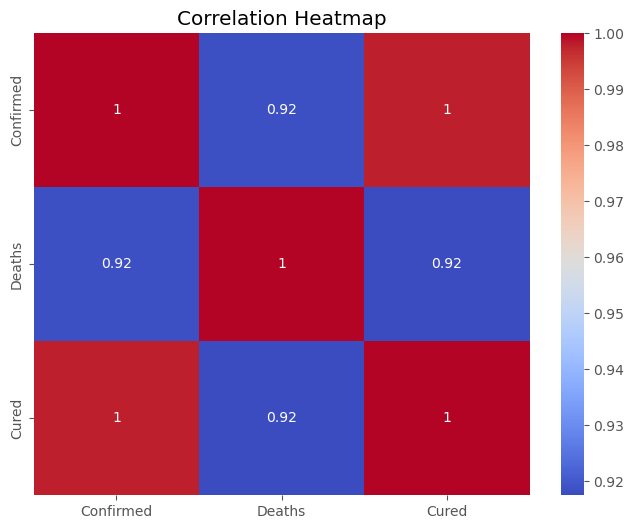

In [16]:
#Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    covid[['Confirmed', 'Deaths', 'Cured']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig(
    "visuals/correlation_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

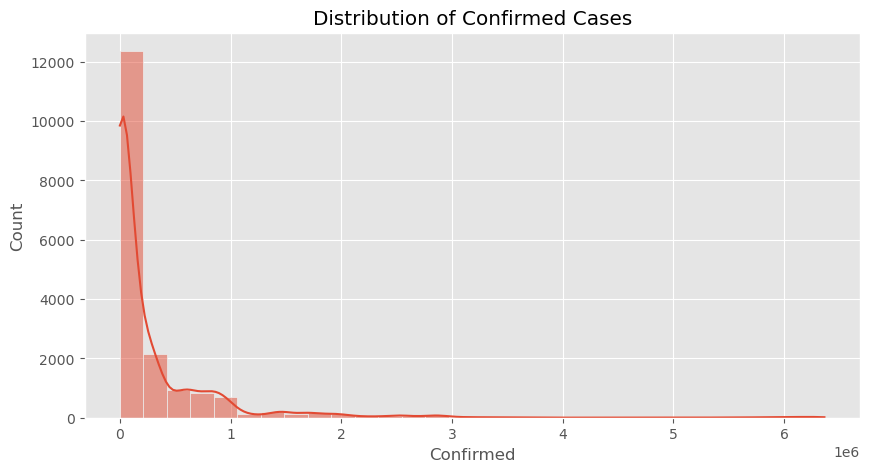

In [17]:
#Distribution Plot
plt.figure(figsize=(10,5))

sns.histplot(
    covid['Confirmed'],
    bins=30,
    kde=True
)

plt.title("Distribution of Confirmed Cases")

plt.savefig(
    "visuals/confirmed_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

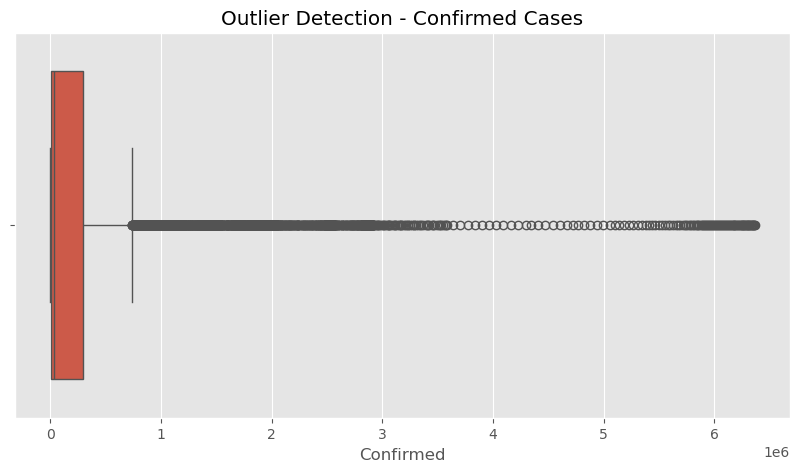

In [18]:
#Boxplot - Outlier Detection
plt.figure(figsize=(10,5))

sns.boxplot(
    x=covid['Confirmed']
)

plt.title("Outlier Detection - Confirmed Cases")

plt.savefig(
    "visuals/confirmed_boxplot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

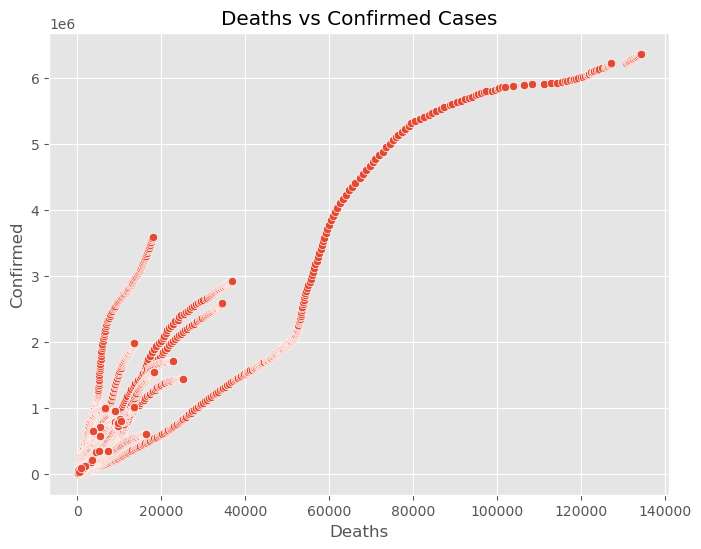

In [19]:
#Scatter Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Deaths',
    y='Confirmed',
    data=covid
)

plt.title("Deaths vs Confirmed Cases")

plt.savefig(
    "visuals/deaths_vs_confirmed.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

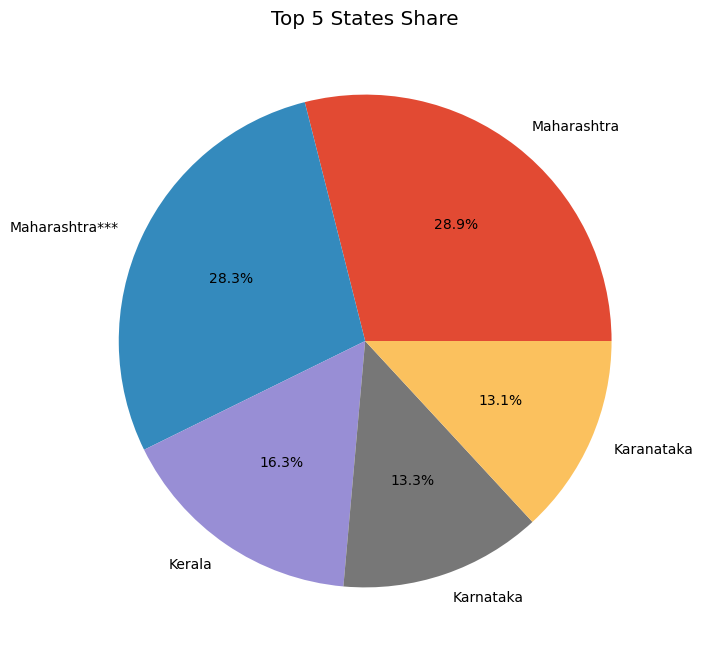

In [20]:
#Pie Chart
top5 = state_cases.head(5)

plt.figure(figsize=(8,8))

plt.pie(
    top5,
    labels=top5.index,
    autopct='%1.1f%%'
)

plt.title("Top 5 States Share")

plt.savefig(
    "visuals/top5_states_piechart.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [21]:
#Vaccination Analysis
vaccine['Total Doses Administered'] = pd.to_numeric(
    vaccine['Total Doses Administered'],
    errors='coerce'
)

vaccination = vaccine.groupby(
    'State'
)['Total Doses Administered'].max().sort_values(
    ascending=False
)

print("\nTOP VACCINATED STATES")
print(vaccination.head(10))


TOP VACCINATED STATES
State
India             513228400.0
Uttar Pradesh      54447724.0
Maharashtra        47153366.0
Gujarat            37152375.0
Madhya Pradesh     35456676.0
Rajasthan          35383662.0
Karnataka          33280543.0
West Bengal        32390378.0
Bihar              27834939.0
Tamil Nadu         25522708.0
Name: Total Doses Administered, dtype: float64


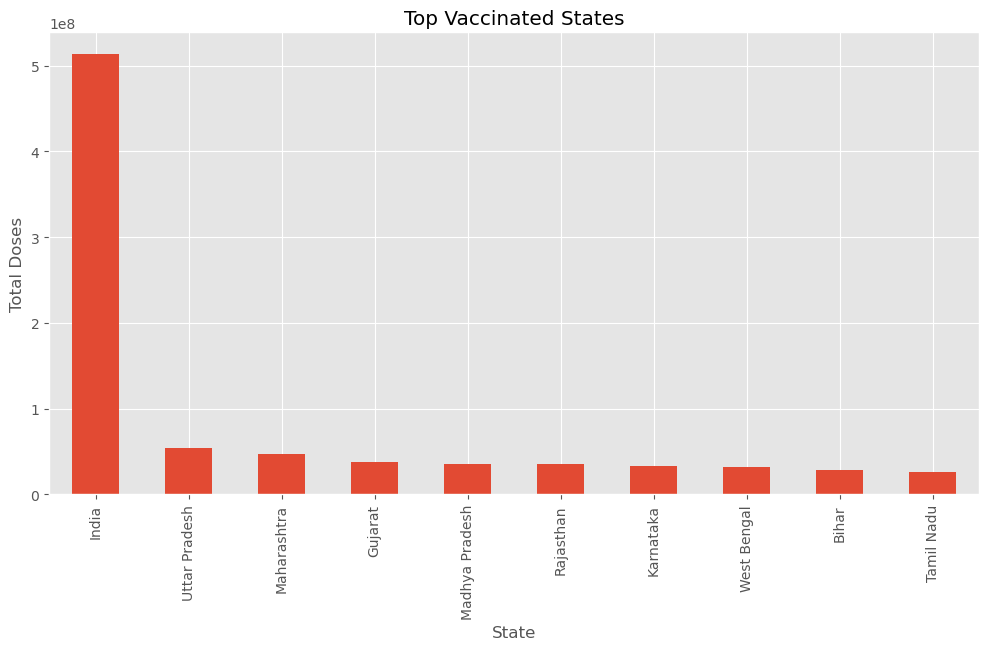

In [22]:
#Vaccination Bar Chart
plt.figure(figsize=(12,6))
vaccination.head(10).plot(kind='bar')
plt.title("Top Vaccinated States")
plt.xlabel("State")
plt.ylabel("Total Doses")

plt.savefig(
    "visuals/top_vaccinated_states.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [23]:
#Generate Report
report = f"""
COVID-19 EXPLORATORY DATA ANALYSIS REPORT
========================================

PROJECT OBJECTIVE
-----------------
Analyze COVID-19 datasets to identify
patterns, trends, and relationships.

DATA CLEANING
-------------
- Handled missing values
- Removed duplicates
- Converted date columns

KEY INSIGHTS
-------------
Total Confirmed Cases:
{total_confirmed}

Total Deaths:
{total_deaths}

Total Recovered Cases:
{total_cured}

TOP 5 STATES
-------------
{state_cases.head(5)}

OBSERVATIONS
-------------
- Confirmed cases increased rapidly over time.
- Strong positive correlation exists between
  confirmed cases and deaths.
- Some states contributed significantly more
  to total cases.
- Vaccination rates varied across states.

TECHNOLOGIES USED
-----------------
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

PROJECT OUTCOME
---------------
Developed analytical thinking and
data exploration skills using
real-world datasets.
"""

with open(
    "reports/final_eda_report.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(report)

print("\nEDA REPORT GENERATED SUCCESSFULLY")


EDA REPORT GENERATED SUCCESSFULLY
